# Voice Data Exploration for Depression Detection

**Purpose**: Explore and validate the raw voice dataset  
**Date**: 2026-02-19  
**Dataset**: `data/raw/voice_data/`

This notebook performs:
- Dataset validation and statistics
- Audio properties analysis
- Waveform and spectrogram visualization
- Class distribution analysis
- Data quality checks

In [1]:
# Import required libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Audio processing
import librosa
import librosa.display

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Dataset Overview

Let's first check if the data directories exist and count the files.

In [2]:
# Check dataset structure
data_dir = Path('../data/raw/voice_data')

depression_dir = data_dir / 'depression1'
normal_dir = data_dir / 'normal1'

print("="*60)
print("Dataset Structure Check")
print("="*60)

# Check if directories exist
print(f"\nData directory: {data_dir}")
print(f"  Exists: {data_dir.exists()}")

print(f"\nDepression directory: {depression_dir}")
print(f"  Exists: {depression_dir.exists()}")

print(f"\nNormal directory: {normal_dir}")
print(f"  Exists: {normal_dir.exists()}")

# Count files
if depression_dir.exists():
    depression_files = list(depression_dir.glob('*.wav'))
    print(f"\n📊 Depression samples: {len(depression_files)}")
else:
    depression_files = []
    print(f"\n⚠️  No depression directory found")

if normal_dir.exists():
    normal_files = list(normal_dir.glob('*.wav'))
    print(f"📊 Normal samples: {len(normal_files)}")
else:
    normal_files = []
    print(f"⚠️  No normal directory found")

total_files = len(depression_files) + len(normal_files)
print(f"\n{'='*60}")
print(f"Total audio files: {total_files}")
print(f"{'='*60}")

Dataset Structure Check

Data directory: ..\data\raw\voice_data
  Exists: True

Depression directory: ..\data\raw\voice_data\depression1
  Exists: True

Normal directory: ..\data\raw\voice_data\normal1
  Exists: True

📊 Depression samples: 400
📊 Normal samples: 400

Total audio files: 800


## 2. Dataset Validation

Validate that audio files are readable and collect basic properties.

In [4]:
def validate_audio_files(file_list, label_name):
    """
    Validate audio files and collect statistics.
    
    Args:
        file_list: List of audio file paths
        label_name: Name of the category (for reporting)
    
    Returns:
        DataFrame with file statistics
    """
    stats = []
    corrupted = []
    
    print(f"\nValidating {label_name} files...")
    
    for i, audio_file in enumerate(file_list):
        try:
            # Load audio
            y, sr = librosa.load(audio_file, sr=None)
            duration = len(y) / sr
            
            # Collect stats
            stats.append({
                'filename': audio_file.name,
                'label': label_name,
                'sample_rate': sr,
                'duration': duration,
                'num_samples': len(y),
                'max_amplitude': np.max(np.abs(y)),
                'rms_energy': np.sqrt(np.mean(y**2))
            })
            
            # Progress indicator
            if (i + 1) % 10 == 0:
                print(f"  Processed {i + 1}/{len(file_list)} files...", end='\r')
                
        except Exception as e:
            print(f"\n  ❌ Error with {audio_file.name}: {e}")
            corrupted.append(audio_file.name)
    
    print(f"  ✓ Completed: {len(stats)}/{len(file_list)} valid files")
    
    if corrupted:
        print(f"  ⚠️  Corrupted files: {len(corrupted)}")
        for f in corrupted:
            print(f"     - {f}")
    
    return pd.DataFrame(stats), corrupted

# Validate both datasets
depression_stats, dep_corrupted = validate_audio_files(depression_files, 'depression')
normal_stats, norm_corrupted = validate_audio_files(normal_files, 'normal')

# Combine results
if len(depression_stats) > 0 and len(normal_stats) > 0:
    all_stats = pd.concat([depression_stats, normal_stats], ignore_index=True)
elif len(depression_stats) > 0:
    all_stats = depression_stats
elif len(normal_stats) > 0:
    all_stats = normal_stats
else:
    all_stats = pd.DataFrame()

print(f"\n{'='*60}")
print(f"Total valid files: {len(all_stats)}")
print(f"{'='*60}")


Validating depression files...
  ✓ Completed: 400/400 valid files

Validating normal files...
  ✓ Completed: 400/400 valid files

Total valid files: 800


## 3. Dataset Statistics

Analyze the properties of our audio files.

In [5]:
if len(all_stats) > 0:
    print("="*60)
    print("Dataset Statistics Summary")
    print("="*60)
    
    # Overall statistics
    print("\nOverall Statistics:")
    print(all_stats.describe())
    
    # Group by label
    print("\n" + "="*60)
    print("Statistics by Label:")
    print("="*60)
    
    for label in all_stats['label'].unique():
        label_data = all_stats[all_stats['label'] == label]
        print(f"\n{label.upper()}:")
        print(f"  Count: {len(label_data)}")
        print(f"  Duration (mean): {label_data['duration'].mean():.2f}s")
        print(f"  Duration (std): {label_data['duration'].std():.2f}s")
        print(f"  Duration (min): {label_data['duration'].min():.2f}s")
        print(f"  Duration (max): {label_data['duration'].max():.2f}s")
        print(f"  Sample Rate (mode): {label_data['sample_rate'].mode()[0] if len(label_data) > 0 else 'N/A'} Hz")
        print(f"  Total Duration: {label_data['duration'].sum()/60:.2f} minutes")
    
    # Check class balance
    print("\n" + "="*60)
    print("Class Distribution:")
    print("="*60)
    class_counts = all_stats['label'].value_counts()
    print(class_counts)
    
    if len(class_counts) == 2:
        ratio = class_counts.iloc[0] / class_counts.iloc[1]
        print(f"\nClass ratio: {ratio:.2f}")
        if 0.8 <= ratio <= 1.2:
            print("✓ Dataset is reasonably balanced")
        else:
            print("⚠️  Dataset is imbalanced - consider balancing techniques")
else:
    print("⚠️  No valid audio files found. Please populate the dataset first.")

Dataset Statistics Summary

Overall Statistics:
       sample_rate    duration   num_samples  max_amplitude  rms_energy
count        800.0  800.000000    800.000000     800.000000  800.000000
mean       24414.0    2.228302  54401.768750       0.127391    0.025388
std            0.0    0.236283   5768.619681       0.085408    0.013944
min        24414.0    1.723806  42085.000000       0.032837    0.008512
25%        24414.0    2.048599  50014.500000       0.059151    0.013166
50%        24414.0    2.194397  53574.000000       0.097549    0.019259
75%        24414.0    2.392265  58404.750000       0.185715    0.037063
max        24414.0    2.984804  72871.000000       0.798706    0.083392

Statistics by Label:

DEPRESSION:
  Count: 400
  Duration (mean): 2.40s
  Duration (std): 0.19s
  Duration (min): 1.94s
  Duration (max): 2.98s
  Sample Rate (mode): 24414 Hz
  Total Duration: 16.01 minutes

NORMAL:
  Count: 400
  Duration (mean): 2.05s
  Duration (std): 0.12s
  Duration (min): 1.72s
 

## 4. Audio Properties Visualization

Visualize the distribution of key audio properties.

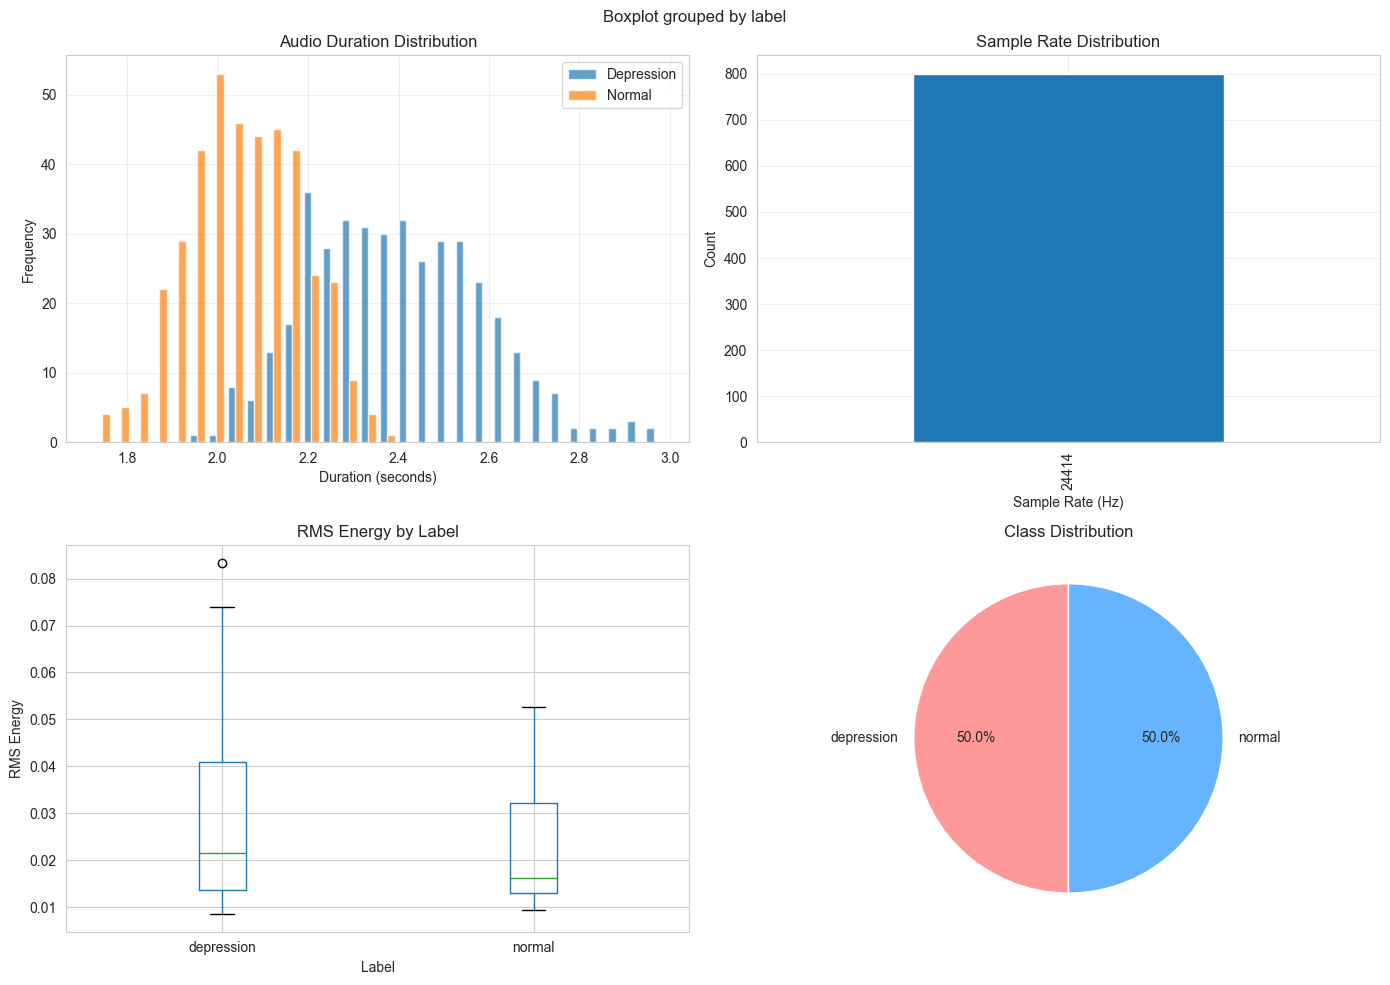

✓ Audio properties visualized


In [6]:
if len(all_stats) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Duration distribution
    axes[0, 0].hist([all_stats[all_stats['label']=='depression']['duration'],
                     all_stats[all_stats['label']=='normal']['duration']],
                    bins=30, label=['Depression', 'Normal'], alpha=0.7)
    axes[0, 0].set_xlabel('Duration (seconds)')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Audio Duration Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Sample rate distribution
    all_stats['sample_rate'].value_counts().plot(kind='bar', ax=axes[0, 1])
    axes[0, 1].set_xlabel('Sample Rate (Hz)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Sample Rate Distribution')
    axes[0, 1].grid(alpha=0.3)
    
    # RMS Energy comparison
    all_stats.boxplot(column='rms_energy', by='label', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Label')
    axes[1, 0].set_ylabel('RMS Energy')
    axes[1, 0].set_title('RMS Energy by Label')
    plt.sca(axes[1, 0])
    plt.xticks(rotation=0)
    
    # Class distribution pie chart
    class_counts = all_stats['label'].value_counts()
    axes[1, 1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
                   colors=['#ff9999', '#66b3ff'], startangle=90)
    axes[1, 1].set_title('Class Distribution')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Audio properties visualized")
else:
    print("⚠️  No data to visualize. Please add audio files to the dataset.")

## 5. Sample Audio Waveform Analysis

Let's examine a few sample waveforms from each class.

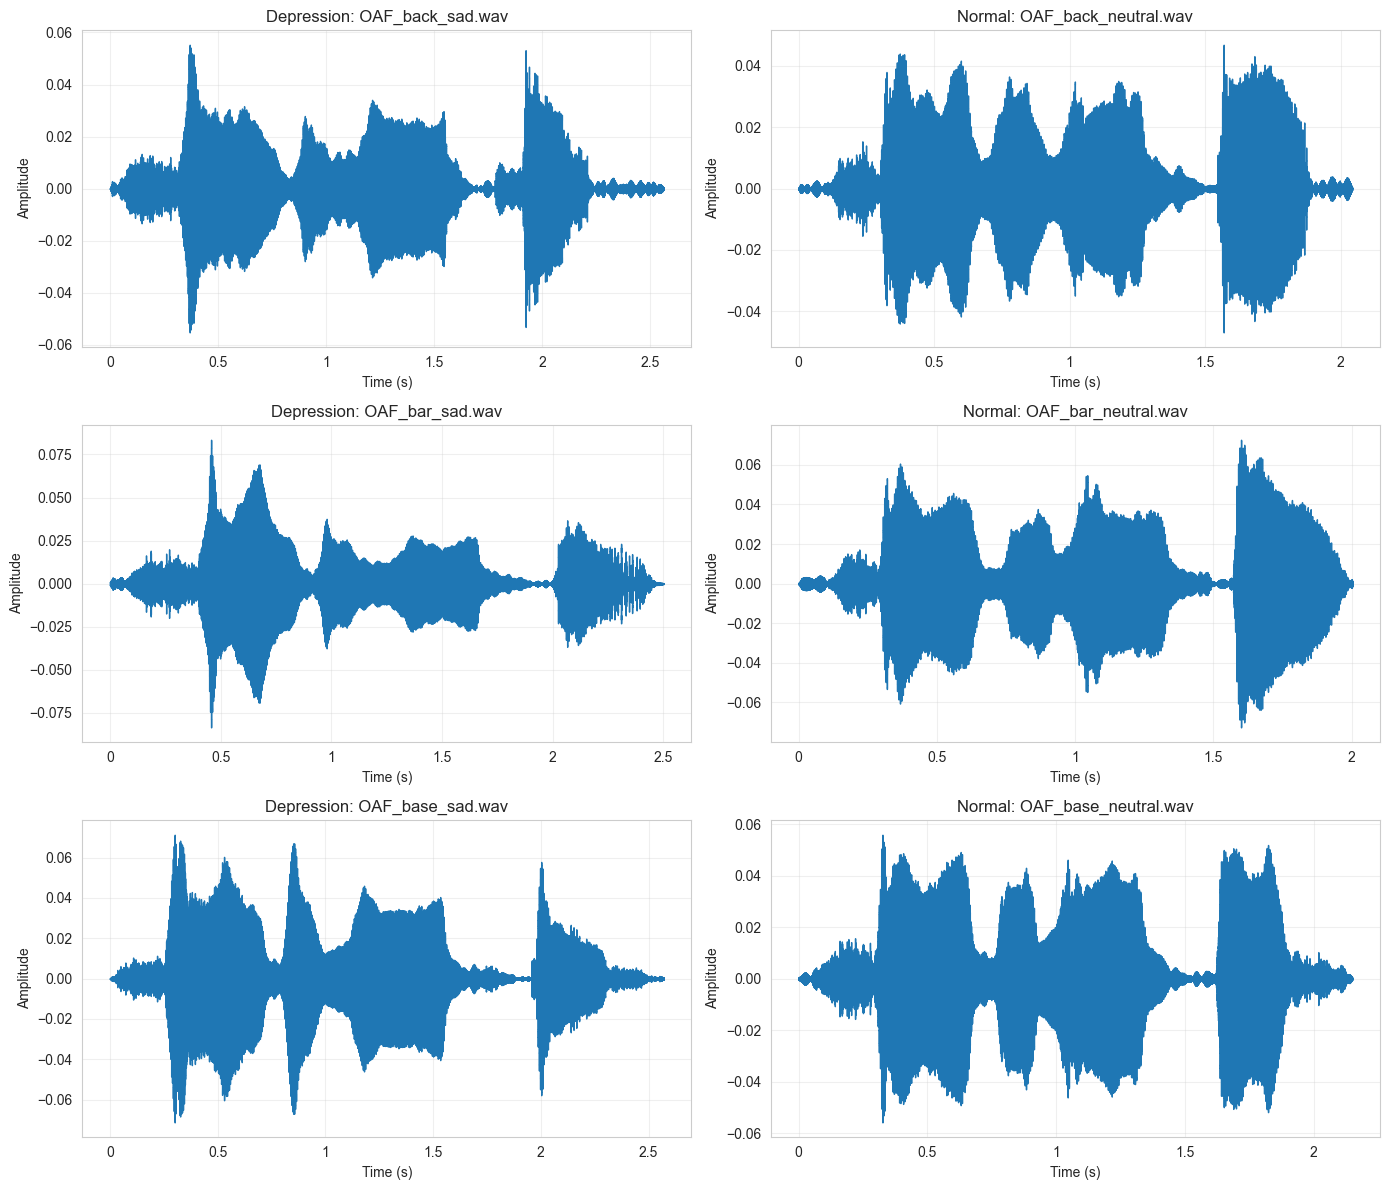

✓ Displayed 3 sample waveforms from each class


In [7]:
def plot_waveform(audio_path, title, ax):
    """Plot audio waveform."""
    y, sr = librosa.load(audio_path, sr=16000)
    
    # Plot waveform
    librosa.display.waveshow(y, sr=sr, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.grid(alpha=0.3)

if len(depression_files) > 0 and len(normal_files) > 0:
    # Select random samples
    n_samples = min(3, len(depression_files), len(normal_files))
    
    fig, axes = plt.subplots(n_samples, 2, figsize=(14, 4*n_samples))
    
    if n_samples == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_samples):
        # Depression sample
        dep_file = depression_files[i]
        plot_waveform(dep_file, f'Depression: {dep_file.name}', axes[i, 0])
        
        # Normal sample
        norm_file = normal_files[i]
        plot_waveform(norm_file, f'Normal: {norm_file.name}', axes[i, 1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Displayed {n_samples} sample waveforms from each class")
elif len(depression_files) > 0 or len(normal_files) > 0:
    print("⚠️  Only one class has samples. Add samples to both classes for comparison.")
else:
    print("⚠️  No audio files found. Please populate the dataset.")

## 6. Spectrogram Visualization

Visualize spectrograms to see frequency content over time.

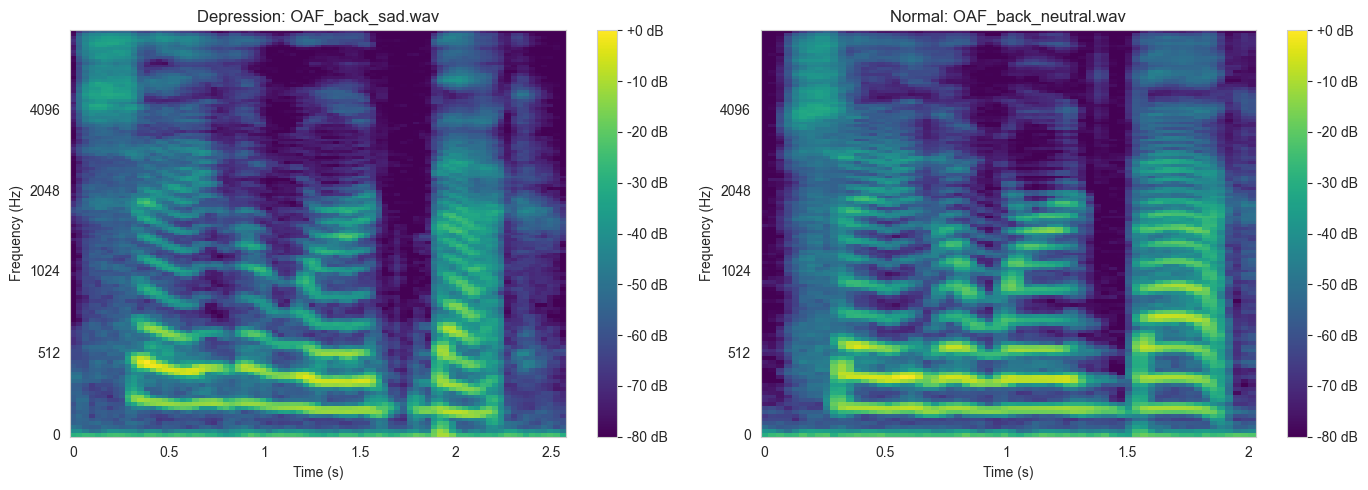

✓ Spectrograms displayed


In [8]:
def plot_spectrogram(audio_path, title, ax):
    """Plot mel-spectrogram."""
    y, sr = librosa.load(audio_path, sr=16000)
    
    # Compute mel-spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Plot
    img = librosa.display.specshow(mel_spec_db, x_axis='time', y_axis='mel',
                                    sr=sr, ax=ax, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Frequency (Hz)')
    
    return img

if len(depression_files) > 0 and len(normal_files) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Use first sample from each class
    img1 = plot_spectrogram(depression_files[0], 
                            f'Depression: {depression_files[0].name}',
                            axes[0])
    img2 = plot_spectrogram(normal_files[0],
                            f'Normal: {normal_files[0].name}',
                            axes[1])
    
    # Add colorbars
    fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
    fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Spectrograms displayed")
elif len(depression_files) > 0 or len(normal_files) > 0:
    print("⚠️  Only one class has samples. Add samples to both classes for comparison.")
else:
    print("⚠️  No audio files found. Please populate the dataset.")

## 7. MFCC Feature Preview

Extract and visualize MFCC features (what the model will use).

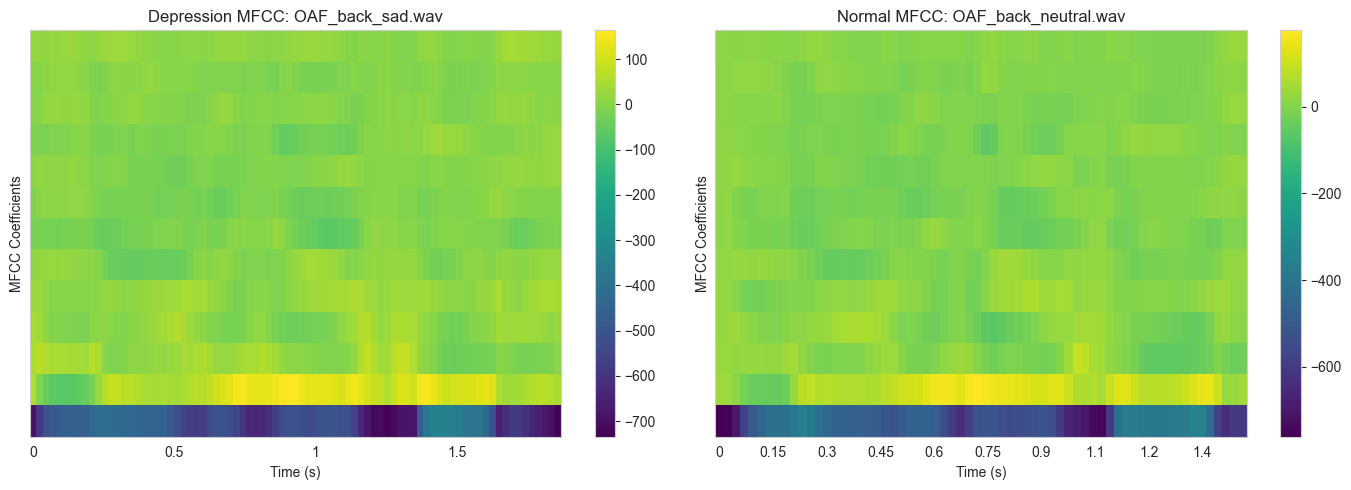

✓ MFCC features displayed

MFCC shapes:
  Depression: (13, 81)
  Normal: (13, 64)

Expected shape for 5s audio @ 16kHz: (13, ~215)


In [9]:
def plot_mfcc(audio_path, title, ax):
    """Plot MFCC features."""
    y, sr = librosa.load(audio_path, sr=16000)
    
    # Extract MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    
    # Plot
    img = librosa.display.specshow(mfccs, x_axis='time', ax=ax, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('MFCC Coefficients')
    
    return img, mfccs

if len(depression_files) > 0 and len(normal_files) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Extract and plot MFCCs
    img1, mfcc_dep = plot_mfcc(depression_files[0],
                               f'Depression MFCC: {depression_files[0].name}',
                               axes[0])
    img2, mfcc_norm = plot_mfcc(normal_files[0],
                                f'Normal MFCC: {normal_files[0].name}',
                                axes[1])
    
    # Add colorbars
    fig.colorbar(img1, ax=axes[0])
    fig.colorbar(img2, ax=axes[1])
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ MFCC features displayed")
    print(f"\nMFCC shapes:")
    print(f"  Depression: {mfcc_dep.shape}")
    print(f"  Normal: {mfcc_norm.shape}")
    print(f"\nExpected shape for 5s audio @ 16kHz: (13, ~215)")
elif len(depression_files) > 0 or len(normal_files) > 0:
    print("⚠️  Only one class has samples. Add samples to both classes for comparison.")
else:
    print("⚠️  No audio files found. Please populate the dataset.")

## 8. Data Quality Recommendations

Based on the exploration, provide recommendations for next steps.

In [10]:
print("="*60)
print("DATA QUALITY RECOMMENDATIONS")
print("="*60)

if len(all_stats) == 0:
    print("\n❌ NO DATA FOUND")
    print("\nAction Required:")
    print("1. Populate data/raw/voice_data/depression1/ with depression audio samples")
    print("2. Populate data/raw/voice_data/normal1/ with normal audio samples")
    print("3. Re-run this notebook to validate the data")
    print("\nSee data/raw/README.md for guidance on organizing your data.")
    
elif len(all_stats) > 0:
    print("\n✓ Data Found")
    print(f"  Total samples: {len(all_stats)}")
    
    # Check sample count
    print("\n1. Sample Count:")
    if len(all_stats) < 100:
        print("   ⚠️  LOW - You have fewer than 100 samples")
        print("   Recommendation: Aim for at least 200-500 samples per class")
    elif len(all_stats) < 500:
        print("   ⚠️  MODERATE - Decent for initial experiments")
        print("   Recommendation: Consider gathering more data for production models")
    else:
        print("   ✓ GOOD - Sufficient samples for training")
    
    # Check balance
    print("\n2. Class Balance:")
    class_counts = all_stats['label'].value_counts()
    if len(class_counts) == 2:
        ratio = class_counts.iloc[0] / class_counts.iloc[1]
        if 0.8 <= ratio <= 1.2:
            print("   ✓ BALANCED - Classes are well-balanced")
        else:
            print(f"   ⚠️  IMBALANCED - Ratio: {ratio:.2f}")
            print("   Recommendation: Balance classes or use class weights during training")
    else:
        print("   ❌ MISSING CLASS - Only one class found")
        print("   Recommendation: Add samples for both depression and normal classes")
    
    # Check duration consistency
    print("\n3. Duration Consistency:")
    duration_std = all_stats['duration'].std()
    duration_mean = all_stats['duration'].mean()
    if duration_std / duration_mean < 0.2:
        print(f"   ✓ CONSISTENT - Audio durations are uniform (mean: {duration_mean:.2f}s)")
    else:
        print(f"   ⚠️  VARIABLE - Durations vary significantly")
        print(f"   Mean: {duration_mean:.2f}s, Std: {duration_std:.2f}s")
        print("   Recommendation: Consider trimming/padding to fixed length (5s recommended)")
    
    # Check sample rate
    print("\n4. Sample Rate:")
    sr_counts = all_stats['sample_rate'].value_counts()
    if len(sr_counts) == 1:
        print(f"   ✓ CONSISTENT - All files at {sr_counts.index[0]} Hz")
    else:
        print(f"   ⚠️  MIXED - Multiple sample rates detected")
        print("   Recommendation: Resample all to 16kHz during preprocessing")
    
    # Next steps
    print("\n" + "="*60)
    print("NEXT STEPS")
    print("="*60)
    print("\n1. ✓ Data exploration complete")
    print("2. → Preprocess audio (clean, normalize, resample to 16kHz)")
    print("3. → Extract MFCC features and create train/val/test splits")
    print("4. → Train baseline model")
    print("5. → Evaluate and iterate")
    
print("\n" + "="*60)

DATA QUALITY RECOMMENDATIONS

✓ Data Found
  Total samples: 800

1. Sample Count:
   ✓ GOOD - Sufficient samples for training

2. Class Balance:
   ✓ BALANCED - Classes are well-balanced

3. Duration Consistency:
   ✓ CONSISTENT - Audio durations are uniform (mean: 2.23s)

4. Sample Rate:
   ✓ CONSISTENT - All files at 24414 Hz

NEXT STEPS

1. ✓ Data exploration complete
2. → Preprocess audio (clean, normalize, resample to 16kHz)
3. → Extract MFCC features and create train/val/test splits
4. → Train baseline model
5. → Evaluate and iterate



## Summary

This notebook explored the raw voice dataset and provided insights into:
- Dataset structure and file counts
- Audio properties (duration, sample rate, energy)
- Class distribution and balance
- Visual analysis (waveforms, spectrograms, MFCCs)
- Data quality recommendations

**Next notebook**: Data preprocessing and feature extraction